# Section 5.3 — VSS at the matched configuration $\lvert\Omega\rvert = 146$

A two-run companion to `section_5_3_value_of_stochastic_solution.ipynb`. That notebook
sweeps every scenario tree for which VSS output exists; **this one computes the same
metrics for exactly two runs and compares only those two**:

| Formulation | Run | $\lvert\Omega_0\rvert$ | $\lvert\Omega\rvert$ |
|---|---|---|---|
| **HG** (`same_ren`) | `FTC_20251031_20251130_c30_sc560_15min_same_ren` | 560 | 146 |
| **QHS** (`dif_ren`) | `FTC_20251031_20251130_c30_sc170_15min_different_ren` | 170 | 146 |

### Why this pair

These two runs retain the **same number of scenarios**, and $\lvert\Omega\rvert = 146$ is
the largest retained count both formulations reach — the configuration Section 4.2 uses
for its deep dive, and the only one at which HG attains 146 at all. Holding
$\lvert\Omega\rvert$ fixed removes the two objections that qualify a cross-formulation
VSS comparison drawn from arbitrary runs:

1. **Matching.** Both models saw a tree of the same size, so a difference between their
   chains is not a difference in how much uncertainty each was shown.
2. **Provenance.** Both runs appear in their own branch's execution batch
   (`results_batch_same_ren.csv`, `results_batch_dif_ren.csv`), so their $RP$ values are
   on the same footing as every number in Section 4.2 — unlike the `15min_ren_same`
   branch used by the sweep notebook, whose HG run reconciles with no batch row.

What this pairing does **not** remove is the confounding of `rem:confounding`: a
difference between the two chains is not attributable to the stage structure alone.
Nothing below claims otherwise.

### Metric set

Identical in substance to the sweep notebook, with the across-tree items dropped — with
one run per formulation there is no tree axis to sweep. Item IDs are given as `Mn`, with
the corresponding sweep-notebook item in brackets.

| Item | What it shows |
|---|---|
| **M1** [V1.1, V1.2] | $RP$, $Z_{EV}$, and $Z_{EV} - RP$ |
| **M2** [V1.5, V2.2] | Static chain: $EEV_\tau$, $VSS_\tau$ |
| **M3** [V1.4, V2.3] | Dynamic chain: $EDEV_\tau$, $VSS^D_\tau$, $EDEV^{\mathrm{rec}}_2$ |
| **M4** [V3.1, V3.2] | Both chains side by side, in levels and as differences from $RP$ |
| **M5** [V3.3] | Decomposition of the dynamic gap via $EDEV^{\mathrm{rec}}_2$ |
| **M6** [V3.4] | Where stochasticity matters: static-chain increments |
| **M7** [V2.5, V3.5] | Probability mass discarded, beside the values it produced |
| **M8** [V3.7] | Verification of the properties audited in `tab:props` |
| **M9** [V3.8] | Constraints violated and infeasibility margins — the known gap |

### Data availability

The two runs are pinned by name in the setup cell. Each is loaded independently and the
notebook reports which of the two has VSS output; sections render whatever is present and
say plainly what is missing, so **no cell needs editing once the second run's chain
finishes**. Substituting a different pair is a two-line change in the setup cell.

## 0. Setup

In [1]:
import os
import re
import csv
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

In [2]:
# ---------------------------------------------------------------------------
# The two runs being compared. Changing the comparison is a change to these two
# lines and nothing else.
# ---------------------------------------------------------------------------
REQUESTED_RUNS = {
    "HG":  "FTC_20251031_20251130_c30_sc560_15min_same_ren",
    "QHS": "FTC_20251031_20251130_c30_sc170_15min_different_ren",
}
# The retained count both runs are expected to share. Asserted, not assumed.
EXPECTED_RETAINED = 146

RESULTS_DIR = os.path.join("..", "Execution of model", "results")
BATCH_CSVS = [
    os.path.join("..", "Execution of model", "results_batch_dif_ren.csv"),
    os.path.join("..", "Execution of model", "results_batch_same_ren.csv"),
]

# The six market macro-stages (methods.tex, tab:macro-stages). Both formulations are
# indexed by these same six stages, not by their 30 / 102 decision stages, so the
# two chains share one x-axis with no normalisation.
MACRO_STAGES = ["DA", "RM", "IM1", "IM2", "IM3", "IB"]
TAUS = list(range(1, len(MACRO_STAGES) + 1))
TAU_LAST = TAUS[-1]
STAGE_LABEL = {t: f"{t}\n{MACRO_STAGES[t - 1]}" for t in TAUS}

# validation.py::DEFAULT_TOL -- used for every proposition INEQUALITY, so that M8
# reproduces the shipped validator's verdicts exactly.
VALIDATION_TOL = 1e-6
# Relative tolerance for the tab:props EQUALITY identities. These are ~1e4 EUR
# quantities: an absolute 1e-6 test is a test on the 11th significant digit and
# fails on ordinary solver float noise rather than on anything the theory says.
IDENTITY_REL_TOL = 1e-8

ORDER = ["QHS", "HG"]
COLORS = {"QHS": "#1f77b4", "HG": "#d62728"}
CHAIN_COLORS = {"static": "#2c7fb8", "dynamic": "#e6550d", "recourse": "#756bb1"}
FIGSIZE_SINGLE = (8.5, 4.6)
FIGSIZE_PAIR = (13.5, 4.6)

In [3]:
# ---------------------------------------------------------------------------
# Readers. Identical in behaviour to the sweep notebook's, so the two notebooks
# cannot disagree about what a file means.
# ---------------------------------------------------------------------------
def _read_vss_csv(path, stage_value_col, stage_share_col):
    """Six per-stage rows, a blank separator, then `key,value` trailer rows."""
    stages, trailers = [], {}
    with open(path, newline="") as fh:
        for row in csv.reader(fh):
            if not row or not row[0]:
                continue
            if row[0].isdigit():
                stages.append({
                    "tau": int(row[0]), "macro_stage": row[1],
                    stage_value_col: float(row[2]), stage_share_col: float(row[3]),
                    "excluded_mass": float(row[4]),
                })
            elif row[0] != "stage_t":
                trailers[row[0]] = row[1:]
    return pd.DataFrame(stages), trailers


def read_static(path):
    stages, trailers = _read_vss_csv(path, "EEV", "VSS")
    return stages, {"RP": float(trailers["RP"][0]), "EV": float(trailers["EV"][0])}


def read_dynamic(path):
    stages, trailers = _read_vss_csv(path, "EDEV", "VSSD")
    scalars = {
        "RP_dyn": float(trailers["RP"][0]),
        "VSSD": float(trailers["VSSD"][0]),
        "EDEV_2_recourse": float(trailers["EDEV_2_recourse"][0]),
        "EDEV_2_recourse_excluded_mass": float(trailers["EDEV_2_recourse"][2]),
        "VSSD_2_recourse": float(trailers["VSSD_2_recourse"][0]),
    }
    return stages, scalars


def retained_from_log(path):
    """|Omega| from results_log.res: the LARGEST scenario set the log mentions.

    The log is append-only across re-runs and also records the small per-group EV_g
    subproblems, so a positional read is unsafe; max picks out the full retained tree.
    Validated against num_scenarios_reduced in the sweep notebook.
    """
    if not os.path.exists(path):
        return np.nan
    with open(path, errors="ignore") as fh:
        found = re.findall(r"card\(S\):\s*([\d.]+)", fh.read())
    return int(max(float(x) for x in found)) if found else np.nan


def equal_within_scale(a, b, rel_tol=IDENTITY_REL_TOL):
    """Scale-aware equality for the tab:props identities."""
    return abs(a - b) <= max(VALIDATION_TOL, rel_tol * max(abs(a), abs(b)))

In [4]:
# ---------------------------------------------------------------------------
# Load the two pinned runs. A run without VSS CSVs is recorded as unavailable
# rather than raising: the RP solve may exist long before its chains do.
# ---------------------------------------------------------------------------
batch = pd.concat([pd.read_csv(p) for p in BATCH_CSVS], ignore_index=True)
batch["run_dir"] = (batch["results_dir"].astype(str)
                    .str.replace("\\", "/", regex=False).str.split("/").str[-4])
batch_lookup = batch.set_index("run_dir")

status_rows, static_parts, dynamic_parts, scalar_rows = [], [], [], []

for formulation, run_dir in REQUESTED_RUNS.items():
    ec_dir = os.path.join(RESULTS_DIR, run_dir, "DA", "ec", "001")
    static_path = os.path.join(ec_dir, "static_vss_results.csv")
    dynamic_path = os.path.join(ec_dir, "edev_vssd_results.csv")
    log_path = os.path.join(ec_dir, "results_log.res")

    row = {
        "formulation": formulation, "run_dir": run_dir,
        "run_dir_exists": os.path.isdir(os.path.join(RESULTS_DIR, run_dir)),
        "has_static_csv": os.path.exists(static_path),
        "has_dynamic_csv": os.path.exists(dynamic_path),
        "has_rp_solve": os.path.exists(log_path),
    }
    bat = batch_lookup.loc[run_dir] if run_dir in batch_lookup.index else None
    row["in_batch"] = bat is not None
    row["batch_obj_fun"] = float(bat["obj_fun"]) if bat is not None else np.nan
    row["batch_pop_initial"] = int(bat["num_scenarios_folder"]) if bat is not None else np.nan
    row["batch_pop_retained"] = (int(bat["num_scenarios_reduced"])
                                 if bat is not None and pd.notna(bat["num_scenarios_reduced"])
                                 else np.nan)
    row["pop_retained_log"] = retained_from_log(log_path)
    row["vss_available"] = row["has_static_csv"] and row["has_dynamic_csv"]

    if row["vss_available"]:
        stat_df, stat_sc = read_static(static_path)
        dyn_df, dyn_sc = read_dynamic(dynamic_path)
        assert abs(stat_sc["RP"] - dyn_sc["RP_dyn"]) < 1e-6, (
            f"{run_dir}: the two VSS CSVs disagree on RP")
        key = {"run_dir": run_dir, "formulation": formulation}
        static_parts.append(stat_df.assign(**key))
        dynamic_parts.append(dyn_df.assign(**key))
        scalar_rows.append({**key, **stat_sc,
                            **{k: v for k, v in dyn_sc.items() if k != "RP_dyn"}})
    status_rows.append(row)

status = pd.DataFrame(status_rows).set_index("formulation").loc[
    [f for f in ORDER if f in REQUESTED_RUNS]].reset_index()

EMPTY_STAGE = pd.DataFrame(columns=["tau", "macro_stage", "excluded_mass",
                                    "run_dir", "formulation"])
static = pd.concat(static_parts, ignore_index=True) if static_parts else EMPTY_STAGE.copy()
dynamic = pd.concat(dynamic_parts, ignore_index=True) if dynamic_parts else EMPTY_STAGE.copy()
scalars = pd.DataFrame(scalar_rows)

AVAILABLE = [f for f in ORDER if f in set(status.loc[status["vss_available"], "formulation"])]
MISSING = [f for f in ORDER if f in REQUESTED_RUNS and f not in AVAILABLE]
BOTH = len(AVAILABLE) == 2

status[["formulation", "run_dir", "run_dir_exists", "has_rp_solve", "in_batch",
        "batch_pop_initial", "batch_pop_retained", "pop_retained_log",
        "has_static_csv", "has_dynamic_csv", "vss_available"]]

,formulation,run_dir,run_dir_exists,has_rp_solve,in_batch,batch_pop_initial,batch_pop_retained,pop_retained_log,has_static_csv,has_dynamic_csv,vss_available
0,QHS,FTC_20251031_20251130_c30_sc170_15min_differen...,True,True,True,170,146,146,True,True,True
1,HG,FTC_20251031_20251130_c30_sc560_15min_same_ren,True,True,True,560,146,146,False,False,False


In [5]:
# ---------------------------------------------------------------------------
# Availability banner. Printed before any figure so no chart below can be read
# without knowing which runs are behind it.
# ---------------------------------------------------------------------------
print("=" * 78)
print("VSS DATA AVAILABILITY FOR THE REQUESTED PAIR")
print("=" * 78)
for r in status.to_dict("records"):
    mark = "OK   " if r["vss_available"] else "ABSENT"
    print(f"  [{mark}] {r['formulation']:4s}  {r['run_dir']}")
    if not r["vss_available"]:
        missing = [n for n, present in [("static_vss_results.csv", r["has_static_csv"]),
                                        ("edev_vssd_results.csv", r["has_dynamic_csv"])]
                   if not present]
        detail = ("the run directory does not exist" if not r["run_dir_exists"]
                  else f"missing {', '.join(missing)}")
        print(f"            {detail}")
        if r["has_rp_solve"]:
            print(f"            the RP solve IS present "
                  f"(batch obj_fun = {r['batch_obj_fun']:,.2f} EUR); only the VSS "
                  f"chains have not been run")
print()

if BOTH:
    print("Both runs have VSS output: every section below renders the full comparison.")
else:
    print(f"ONLY {', '.join(AVAILABLE) or 'NEITHER FORMULATION'} has VSS output.")
    print(f"Sections below render what exists and name {', '.join(MISSING)} as missing.")
    print("No cell needs editing once the missing chain has been run.")
print("=" * 78)

VSS DATA AVAILABILITY FOR THE REQUESTED PAIR
  [OK   ] QHS   FTC_20251031_20251130_c30_sc170_15min_different_ren
  [ABSENT] HG    FTC_20251031_20251130_c30_sc560_15min_same_ren
            missing static_vss_results.csv, edev_vssd_results.csv
            the RP solve IS present (batch obj_fun = -39,026.44 EUR); only the VSS chains have not been run

ONLY QHS has VSS output.
Sections below render what exists and name HG as missing.
No cell needs editing once the missing chain has been run.


In [6]:
# ---------------------------------------------------------------------------
# Matched-count verification. The whole rationale for this pair is that the two
# runs retain the same number of scenarios, so it is asserted rather than trusted.
# ---------------------------------------------------------------------------
status["pop_retained"] = status["batch_pop_retained"].fillna(status["pop_retained_log"])

for r in status.to_dict("records"):
    retained = r["pop_retained"]
    if pd.isna(retained):
        print(f"  {r['formulation']:4s}: |Omega| unknown (no batch row and no solve log)")
        continue
    flag = "" if retained == EXPECTED_RETAINED else "   <-- NOT the expected count"
    print(f"  {r['formulation']:4s}: |Omega_0| = {r['batch_pop_initial']:.0f}, "
          f"|Omega| = {retained:.0f}{flag}")
    if r["in_batch"] and pd.notna(r["pop_retained_log"]):
        assert r["batch_pop_retained"] == r["pop_retained_log"], (
            f"{r['formulation']}: batch and log disagree on |Omega|")

known = status["pop_retained"].dropna()
if len(known) == 2:
    assert known.nunique() == 1, (
        f"the two runs do NOT retain the same number of scenarios: {list(known)} -- "
        "the comparison in this notebook is not a matched one")
    print(f"\nMatched: both runs retain |Omega| = {int(known.iloc[0])}.")
else:
    print("\nMatch not yet verifiable: |Omega| is known for only one of the two runs.")

  QHS : |Omega_0| = 170, |Omega| = 146
  HG  : |Omega_0| = 560, |Omega| = 146

Matched: both runs retain |Omega| = 146.


In [7]:
# ---------------------------------------------------------------------------
# Provenance: every RP must reconcile with its own branch's execution batch, so
# that the euro values here sit on the same footing as Section 4.2's.
# ---------------------------------------------------------------------------
if scalars.empty:
    print("No VSS output loaded; nothing to reconcile yet.")
    provenance = pd.DataFrame()
else:
    provenance = scalars[["formulation", "run_dir", "RP"]].merge(
        status[["run_dir", "batch_obj_fun", "in_batch", "pop_retained"]], on="run_dir")
    provenance["RP_minus_obj_fun"] = provenance["RP"] - provenance["batch_obj_fun"]
    provenance["reconciles"] = provenance["RP_minus_obj_fun"].abs() < 1e-3
    for r in provenance.to_dict("records"):
        verdict = ("reconciles exactly" if r["reconciles"]
                   else ("does NOT reconcile" if r["in_batch"]
                         else "has no batch row to reconcile against"))
        print(f"  {r['formulation']:4s}: RP = {r['RP']:>12,.2f} EUR   {verdict}")

# Derived quantities used throughout.
if not scalars.empty:
    rp_map = scalars.set_index("run_dir")["RP"]
    for frame in (static, dynamic):
        frame["RP"] = frame["run_dir"].map(rp_map)
    static["VSS_pct_RP"] = 100.0 * static["VSS"] / static["RP"].abs()
    dynamic["VSSD_pct_RP"] = 100.0 * dynamic["VSSD"] / dynamic["RP"].abs()
    scalars["EV_minus_RP"] = scalars["EV"] - scalars["RP"]
    scalars["VSSD_2_recourse_pct_RP"] = (100.0 * scalars["VSSD_2_recourse"]
                                         / scalars["RP"].abs())

provenance

  QHS : RP =   -26,860.65 EUR   reconciles exactly


,formulation,run_dir,RP,batch_obj_fun,in_batch,pop_retained,RP_minus_obj_fun,reconciles
0,QHS,FTC_20251031_20251130_c30_sc170_15min_differen...,-26860.648227,-26860.648227,True,146,3.637979e-12,True


In [8]:
# ---------------------------------------------------------------------------
# Plot helpers. With one run per formulation every series is a single line, so
# these are deliberately simpler than the sweep notebook's band machinery.
# ---------------------------------------------------------------------------
def series(frame, formulation, ycol):
    """One formulation's chain, sorted by macro-stage. Empty if it has no data."""
    sub = frame[frame["formulation"] == formulation]
    return sub.sort_values("tau") if not sub.empty else sub


def stage_axis(ax):
    ax.set_xticks(TAUS)
    ax.set_xticklabels([STAGE_LABEL[t] for t in TAUS])
    ax.set_xlabel(r"macro-stage $\tau$")


def zero_line(ax):
    ax.axhline(0.0, color="0.35", lw=0.9, ls="--", zorder=0)


def note_missing(ax):
    """Say on the axes themselves which formulation is absent, so an exported
    figure cannot be mistaken for a complete comparison."""
    if MISSING:
        ax.text(0.99, 0.02, f"{', '.join(MISSING)}: no VSS output",
                transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
                style="italic", color="0.35")


def finish(fig, title=None):
    if title:
        fig.suptitle(title, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()


def bar_positions(labels):
    return np.arange(len(labels))

---
## M1 — $RP$, $Z_{EV}$, and $Z_{EV} - RP$

The reference values every later quantity is a difference of.

$RP$ is the optimal value of the full multistage stochastic model. $Z_{EV}$ is the
optimal value of the classical expected-value problem of `def:static-chain` — the single
deterministic instance in which every stochastic parameter is replaced by its
unconditional expectation over $\Omega$.

The sign of $Z_{EV} - RP$ is the interesting part. A naive Jensen argument would put the
averaged problem above the stochastic one for a maximisation, $Z_{EV} \ge RP$.
`tab:props` records that this reasoning — Escudero's Proposition 2 — is **not applicable**
here, because the objective coefficients are the stochastic market prices rather than
deterministic costs. A negative value is therefore permitted, and observing one is the
cheapest empirical evidence available for a claim `tab:props` otherwise makes on theory
alone.

In [9]:
if scalars.empty:
    print("M1 not computable: no VSS output for either run.")
else:
    m1 = (scalars[["formulation", "run_dir", "RP", "EV", "EV_minus_RP"]]
          .merge(status[["run_dir", "batch_pop_initial", "pop_retained"]], on="run_dir")
          .rename(columns={"batch_pop_initial": "pop_initial"}))
    m1["jensen_ordering_holds"] = m1["EV_minus_RP"] >= 0
    m1 = m1.set_index("formulation").reindex([f for f in ORDER if f in AVAILABLE])
    display_cols = ["pop_initial", "pop_retained", "RP", "EV", "EV_minus_RP",
                    "jensen_ordering_holds"]
    print("M1 -- reference values at the matched configuration")
    if MISSING:
        print(f"     ({', '.join(MISSING)} absent -- see the availability banner)")
    print(m1[display_cols].round(2).to_string())

M1 -- reference values at the matched configuration
     (HG absent -- see the availability banner)
             pop_initial  pop_retained        RP        EV  EV_minus_RP  jensen_ordering_holds
formulation                                                                                   
QHS                  170           146 -26860.65 -27007.26      -146.62                  False


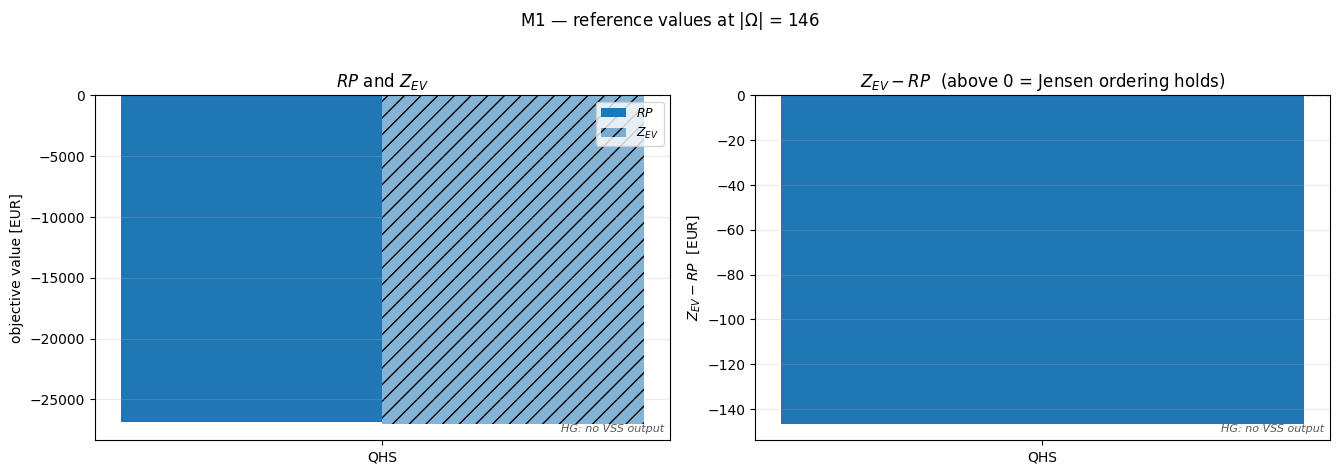

In [10]:
if scalars.empty:
    print("M1 figure not rendered: no VSS output.")
else:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR)
    labels = [f for f in ORDER if f in AVAILABLE]
    pos = bar_positions(labels)
    width = 0.36

    rp_vals = [float(m1.loc[f, "RP"]) for f in labels]
    ev_vals = [float(m1.loc[f, "EV"]) for f in labels]
    axes[0].bar(pos - width / 2, rp_vals, width, label="$RP$",
                color=[COLORS[f] for f in labels])
    axes[0].bar(pos + width / 2, ev_vals, width, label="$Z_{EV}$",
                color=[COLORS[f] for f in labels], alpha=0.55, hatch="//")
    axes[0].set_ylabel("objective value [EUR]")
    axes[0].set_title("$RP$ and $Z_{EV}$")
    axes[0].legend(fontsize=9)

    diff_vals = [float(m1.loc[f, "EV_minus_RP"]) for f in labels]
    axes[1].bar(pos, diff_vals, 0.5, color=[COLORS[f] for f in labels])
    zero_line(axes[1])
    axes[1].set_ylabel(r"$Z_{EV} - RP$  [EUR]")
    axes[1].set_title(r"$Z_{EV} - RP$  (above 0 = Jensen ordering holds)")

    for ax in axes:
        ax.set_xticks(pos)
        ax.set_xticklabels(labels)
        ax.grid(alpha=0.25, axis="y")
        note_missing(ax)

    finish(fig, rf"M1 — reference values at $|\Omega|$ = {EXPECTED_RETAINED}")

---
## M2 — The static chain: $EEV_\tau$ and $VSS_\tau$

$EEV_\tau$ (`def:static-chain`) fixes the decisions newly committed at macro-stages
$1,\dots,\tau-1$ at the classical expected-value solution, broadcast identically to every
scenario, and re-solves the remainder as genuine joint recourse over all of $\Omega$.
Because that *adds* constraints to $RP$ and removes none, `prop:static-guarantee` makes

$$EEV_{\tau+1} \le EEV_\tau, \qquad 0 \le VSS_\tau \le VSS_{\tau+1}$$

theorems in this application — the argument uses only an inclusion of feasible sets and
makes no hypothesis on the constraint matrices or the objective coefficients. $VSS_1 = 0$
by construction, since $EEV_1 := RP$.

Reported in euro and as a share of $\lvert RP \rvert$. At a matched $\lvert\Omega\rvert$
both units are legitimate, but the two formulations' $RP$ differ substantially, so the
share is what makes the *magnitudes* comparable rather than merely the shapes.

In [11]:
if static.empty:
    print("M2 not computable: no static chain for either run.")
else:
    m2 = (static.pivot_table(index="tau", columns="formulation",
                             values=["EEV", "VSS", "VSS_pct_RP"])
          .round(2))
    m2.columns = [f"{form}.{field}" for field, form in m2.columns]
    m2.insert(0, "macro_stage", [MACRO_STAGES[t - 1] for t in m2.index])
    print("M2 -- static chain by macro-stage")
    print(m2.to_string())

M2 -- static chain by macro-stage
    macro_stage   QHS.EEV  QHS.VSS  QHS.VSS_pct_RP
tau                                               
1            DA -26860.65     0.00            0.00
2            RM -26958.01    97.36            0.36
3           IM1 -27349.51   488.86            1.82
4           IM2 -27471.24   610.59            2.27
5           IM3 -27531.43   670.78            2.50
6            IB -27630.31   769.66            2.87


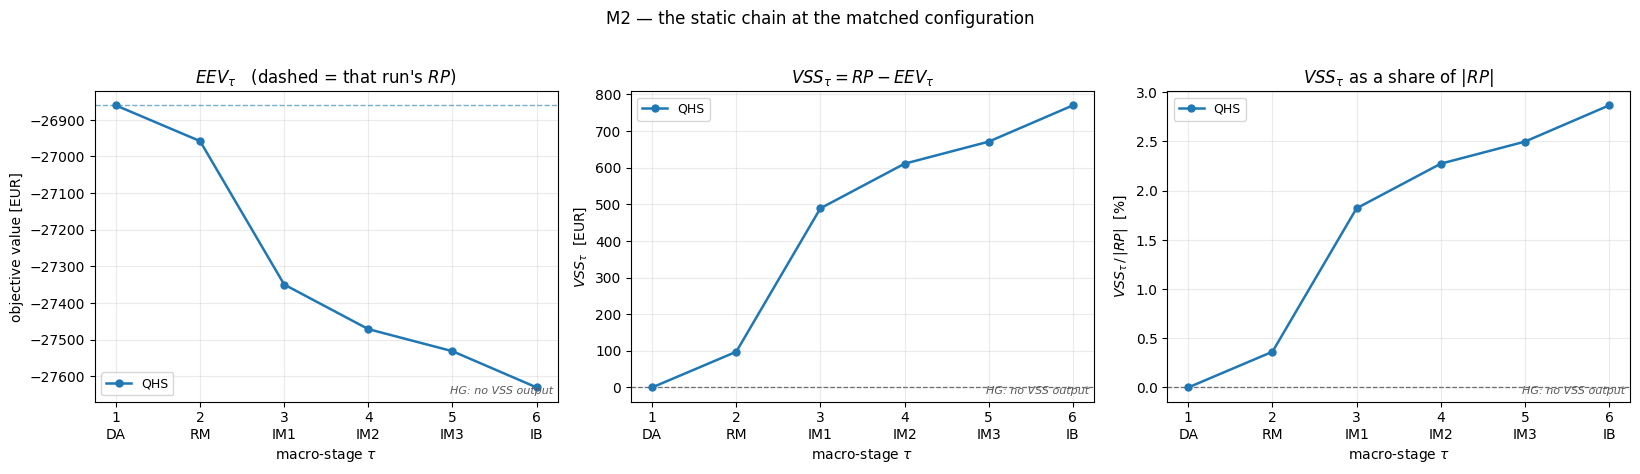

In [12]:
if static.empty:
    print("M2 figure not rendered: no static chain.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
    for form in AVAILABLE:
        s = series(static, form, "EEV")
        axes[0].plot(s["tau"], s["EEV"], color=COLORS[form], marker="o", ms=5,
                     lw=1.8, label=form)
        axes[1].plot(s["tau"], s["VSS"], color=COLORS[form], marker="o", ms=5,
                     lw=1.8, label=form)
        axes[2].plot(s["tau"], s["VSS_pct_RP"], color=COLORS[form], marker="o", ms=5,
                     lw=1.8, label=form)
        # RP is where each static chain starts, by definition of EEV_1.
        axes[0].axhline(float(scalars.set_index("formulation").loc[form, "RP"]),
                        color=COLORS[form], lw=1.0, ls="--", alpha=0.6)

    axes[0].set_ylabel("objective value [EUR]")
    axes[0].set_title(r"$EEV_\tau$   (dashed = that run's $RP$)")
    axes[1].set_ylabel(r"$VSS_\tau$  [EUR]")
    axes[1].set_title(r"$VSS_\tau = RP - EEV_\tau$")
    axes[2].set_ylabel(r"$VSS_\tau \,/\, |RP|$  [%]")
    axes[2].set_title(r"$VSS_\tau$ as a share of $|RP|$")

    for ax in axes:
        stage_axis(ax)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)
        note_missing(ax)
    for ax in axes[1:]:
        zero_line(ax)

    finish(fig, r"M2 — the static chain at the matched configuration")

---
## M3 — The dynamic chain: $EDEV_\tau$, $VSS^D_\tau$ and $EDEV^{\mathrm{rec}}_2$

The dynamic construction (`def:dynamic-chain`) replaces the single average by a family of
**group-conditional** averages, one per scenario group, refined as the tree branches:

$$EDEV_\tau = \sum_{g \in \mathcal{G}_\tau} w^g\, Z^g_{EV}, \qquad VSS^D_\tau = RP - EDEV_\tau$$

It represents a decision-maker who re-optimises against a fresh conditional forecast at
every market session but never engages genuine joint recourse.

**Its guarantee does not hold in this model.** `prop:vssd-failure` shows that each $EV_g$
is a single-scenario problem in which the day-ahead monotonicity set `eq:da-mono` is
instantiated with zero rows, so the groups choose their day-ahead quantities blind to one
another; the point assembled from them is not $RP$-feasible in general, and the inference
$EDEV_T \le RP$ fails. `tab:props` therefore lists Propositions 5, 6 and 7 as **not
guaranteed**, and the methods chapter states directly that an observation of
$VSS^D < 0$ *"is not evidence of an implementation error"*.

$EDEV^{\mathrm{rec}}_2$ (`def:edev2rec`) is the supplementary comparator: it fixes the
day-ahead decisions at each group's own $EV_g$ solution and then solves RM through IB
with **genuine, non-averaged recourse** over that group's real member scenarios, jointly
and at their true absolute probabilities. It is used in M5.

In [13]:
if dynamic.empty:
    print("M3 not computable: no dynamic chain for either run.")
else:
    m3 = (dynamic.pivot_table(index="tau", columns="formulation",
                              values=["EDEV", "VSSD", "VSSD_pct_RP"])
          .round(2))
    m3.columns = [f"{form}.{field}" for field, form in m3.columns]
    m3.insert(0, "macro_stage", [MACRO_STAGES[t - 1] for t in m3.index])
    print("M3 -- dynamic chain by macro-stage")
    print(m3.to_string())
    print()
    rec = (scalars.set_index("formulation")
           [["EDEV_2_recourse", "VSSD_2_recourse", "VSSD_2_recourse_pct_RP",
             "EDEV_2_recourse_excluded_mass"]]
           .reindex([f for f in ORDER if f in AVAILABLE]))
    print("The supplementary comparator EDEV_2_recourse:")
    print(rec.round(4).to_string())

M3 -- dynamic chain by macro-stage
    macro_stage  QHS.EDEV  QHS.VSSD  QHS.VSSD_pct_RP
tau                                                 
1            DA -25873.16   -987.49            -3.68
2            RM -25903.47   -957.18            -3.56
3           IM1 -25989.24   -871.41            -3.24
4           IM2 -25989.24   -871.41            -3.24
5           IM3 -26317.77   -542.88            -2.02
6            IB -26377.14   -483.51            -1.80

The supplementary comparator EDEV_2_recourse:
             EDEV_2_recourse  VSSD_2_recourse  VSSD_2_recourse_pct_RP  EDEV_2_recourse_excluded_mass
formulation                                                                                         
QHS              -26394.2337        -466.4146                 -1.7364                            0.0


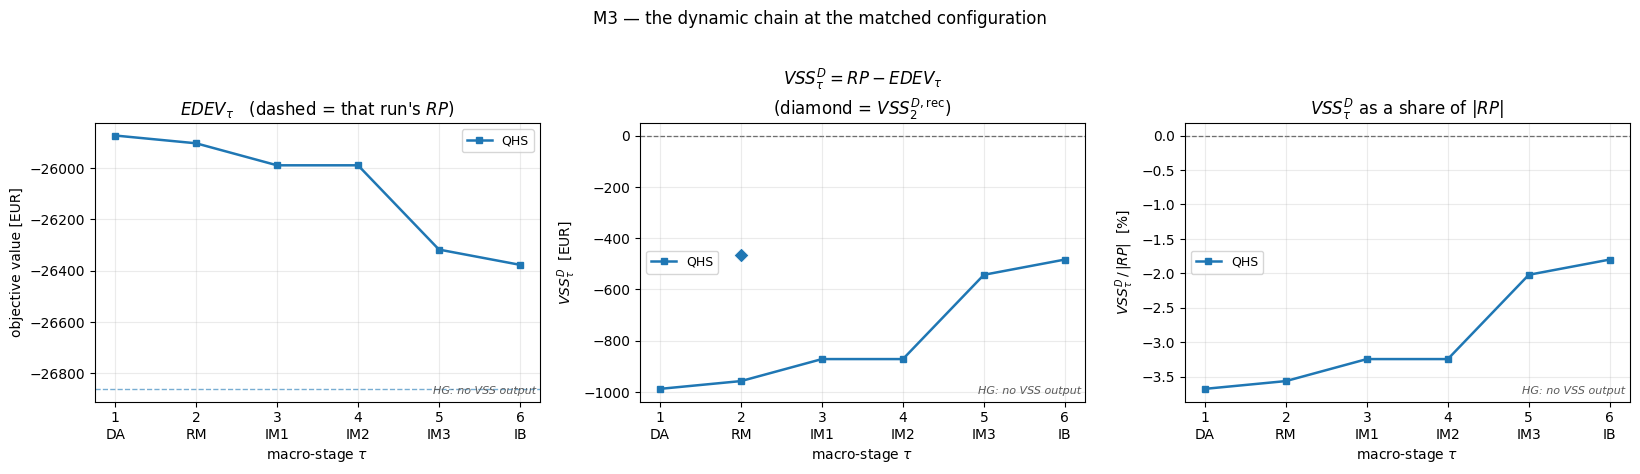

In [14]:
if dynamic.empty:
    print("M3 figure not rendered: no dynamic chain.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
    for form in AVAILABLE:
        d = series(dynamic, form, "EDEV")
        sc = scalars.set_index("formulation").loc[form]
        axes[0].plot(d["tau"], d["EDEV"], color=COLORS[form], marker="s", ms=5,
                     lw=1.8, label=form)
        axes[0].axhline(float(sc["RP"]), color=COLORS[form], lw=1.0, ls="--", alpha=0.6)
        axes[1].plot(d["tau"], d["VSSD"], color=COLORS[form], marker="s", ms=5,
                     lw=1.8, label=form)
        axes[1].scatter([2], [float(sc["VSSD_2_recourse"])], color=COLORS[form],
                        marker="D", s=60, zorder=5, edgecolor="white", lw=0.8)
        axes[2].plot(d["tau"], d["VSSD_pct_RP"], color=COLORS[form], marker="s", ms=5,
                     lw=1.8, label=form)

    axes[0].set_ylabel("objective value [EUR]")
    axes[0].set_title(r"$EDEV_\tau$   (dashed = that run's $RP$)")
    axes[1].set_ylabel(r"$VSS^D_\tau$  [EUR]")
    axes[1].set_title(r"$VSS^D_\tau = RP - EDEV_\tau$"
                      "\n" r"(diamond = $VSS^{D,\mathrm{rec}}_2$)")
    axes[2].set_ylabel(r"$VSS^D_\tau \,/\, |RP|$  [%]")
    axes[2].set_title(r"$VSS^D_\tau$ as a share of $|RP|$")

    for ax in axes:
        stage_axis(ax)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)
        note_missing(ax)
    for ax in axes[1:]:
        zero_line(ax)

    finish(fig, r"M3 — the dynamic chain at the matched configuration")

---
## M4 — Both chains side by side

The chapter's own phrasing for this subsection: the static values and the dynamic values
*"reported side by side."* One panel per formulation, in euro levels, with $RP$ and
$Z_{EV}$ drawn as horizontal rules.

What to read: the static chain starts **on** the $RP$ rule ($EEV_1 = RP$) and descends
below it. The dynamic chain has no such anchor — `tab:props` lists $EDEV_1 = EV$ as
**false here**, because the day-ahead bid curve branches the root into
$\lvert\mathcal{G}_1\rvert \neq 1$ groups (Mismatch 1, `subsec:vss-mismatch`) — and it
sits **above** $RP$. The two chains bracket $RP$ from opposite sides, and the vertical
distance between them is the substantive difference between the two ways of asking what
uncertainty is worth.

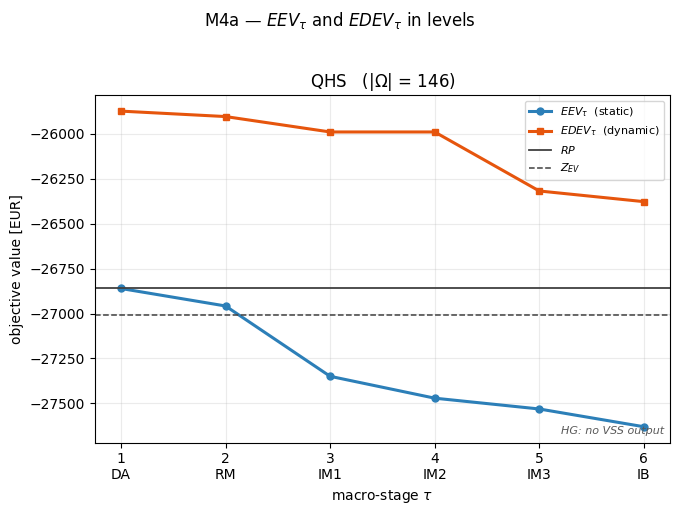

In [15]:
if static.empty or dynamic.empty:
    print("M4 not rendered: both chains are needed and at least one is absent.")
else:
    n_panels = len(AVAILABLE)
    fig, axes = plt.subplots(1, n_panels, figsize=(6.9 * n_panels, 5.0), squeeze=False)
    for ax, form in zip(axes[0], AVAILABLE):
        s, d = series(static, form, "EEV"), series(dynamic, form, "EDEV")
        sc = scalars.set_index("formulation").loc[form]
        ax.plot(s["tau"], s["EEV"], color=CHAIN_COLORS["static"], lw=2.2,
                marker="o", ms=5, label=r"$EEV_\tau$  (static)")
        ax.plot(d["tau"], d["EDEV"], color=CHAIN_COLORS["dynamic"], lw=2.2,
                marker="s", ms=5, label=r"$EDEV_\tau$  (dynamic)")
        ax.axhline(float(sc["RP"]), color="0.25", lw=1.3, label="$RP$")
        ax.axhline(float(sc["EV"]), color="0.25", lw=1.1, ls="--", label="$Z_{EV}$")
        stage_axis(ax)
        retained = status.set_index("formulation").loc[form, "pop_retained"]
        ax.set_title(f"{form}   ($|\\Omega|$ = {retained:.0f})")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    axes[0][0].set_ylabel("objective value [EUR]")
    note_missing(axes[0][-1])
    finish(fig, r"M4a — $EEV_\tau$ and $EDEV_\tau$ in levels")

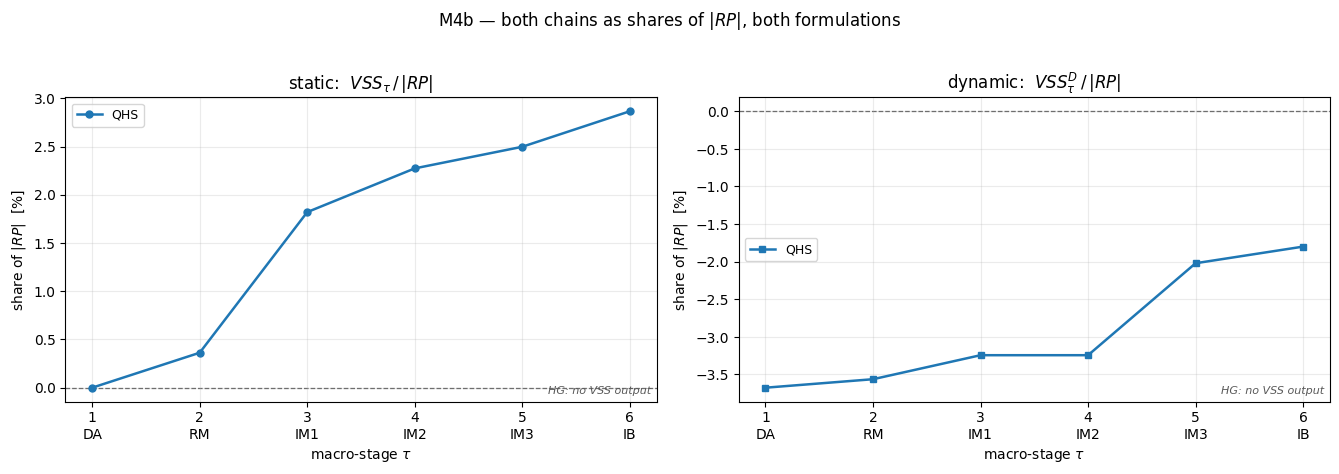

In [16]:
if static.empty or dynamic.empty:
    print("M4b not rendered: both chains are needed.")
else:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharex=True)
    for form in AVAILABLE:
        s, d = series(static, form, "VSS"), series(dynamic, form, "VSSD")
        axes[0].plot(s["tau"], s["VSS_pct_RP"], color=COLORS[form], marker="o",
                     ms=5, lw=1.8, label=form)
        axes[1].plot(d["tau"], d["VSSD_pct_RP"], color=COLORS[form], marker="s",
                     ms=5, lw=1.8, label=form)

    axes[0].set_title(r"static:  $VSS_\tau \,/\, |RP|$")
    axes[1].set_title(r"dynamic:  $VSS^D_\tau \,/\, |RP|$")
    for ax in axes:
        stage_axis(ax)
        zero_line(ax)
        ax.set_ylabel(r"share of $|RP|$  [%]")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)
        note_missing(ax)
    finish(fig, r"M4b — both chains as shares of $|RP|$, both formulations")

---
## M5 — Decomposing the dynamic gap

`subsec:vss-edev2rec` introduces $EDEV^{\mathrm{rec}}_2$ for exactly this purpose and
states that the decomposition *"is reported in Chapter~\ref{chap:results}"*. It splits the
distance between $RP$ and $EDEV_2$ into two pieces with distinct causes:

| Piece | Difference | Attributable to |
|---|---|---|
| **Downstream averaging** | $EDEV_2 - EDEV^{\mathrm{rec}}_2$ | the dynamic chain's continued use of deterministic averaging at every macro-stage after the first |
| **Day-ahead group decomposition** | $EDEV^{\mathrm{rec}}_2 - RP$ | the residual, attributable to the group-decomposed day-ahead decision itself |

The two sum to $EDEV_2 - RP = -VSS^D_2$ by construction, which is asserted below rather
than assumed. Note that $EDEV^{\mathrm{rec}}_2$ does **not** recover the $\le RP$
guarantee: the methods chapter is explicit that it avoids exposing the cross-group
inconsistency to a constraint capable of detecting it, rather than resolving it. Its
purpose is diagnostic.

In [17]:
if dynamic.empty:
    print("M5 not computable: no dynamic chain.")
else:
    gap = (scalars[["formulation", "run_dir", "RP", "EDEV_2_recourse"]]
           .merge(dynamic.loc[dynamic["tau"] == 2, ["run_dir", "EDEV", "VSSD"]]
                  .rename(columns={"EDEV": "EDEV_2", "VSSD": "VSSD_2"}), on="run_dir"))
    gap["downstream_averaging"] = gap["EDEV_2"] - gap["EDEV_2_recourse"]
    gap["group_decomposition"] = gap["EDEV_2_recourse"] - gap["RP"]
    gap["total_gap"] = gap["EDEV_2"] - gap["RP"]

    residual = (gap["downstream_averaging"] + gap["group_decomposition"]
                - gap["total_gap"]).abs().max()
    assert residual < 1e-6, f"gap decomposition does not close: residual {residual:.6f}"
    print(f"decomposition closes exactly (max residual {residual:.2e} EUR)")

    for col in ["downstream_averaging", "group_decomposition", "total_gap"]:
        gap[f"{col}_pct_RP"] = 100.0 * gap[col] / gap["RP"].abs()
    gap = gap.set_index("formulation").reindex([f for f in ORDER if f in AVAILABLE])
    print()
    print(gap[["RP", "EDEV_2_recourse", "EDEV_2", "downstream_averaging",
               "group_decomposition", "total_gap", "downstream_averaging_pct_RP",
               "group_decomposition_pct_RP"]].round(2).to_string())

decomposition closes exactly (max residual 0.00e+00 EUR)

                   RP  EDEV_2_recourse    EDEV_2  downstream_averaging  group_decomposition  total_gap  downstream_averaging_pct_RP  group_decomposition_pct_RP
formulation                                                                                                                                                    
QHS         -26860.65        -26394.23 -25903.47                490.77               466.41     957.18                         1.83                        1.74


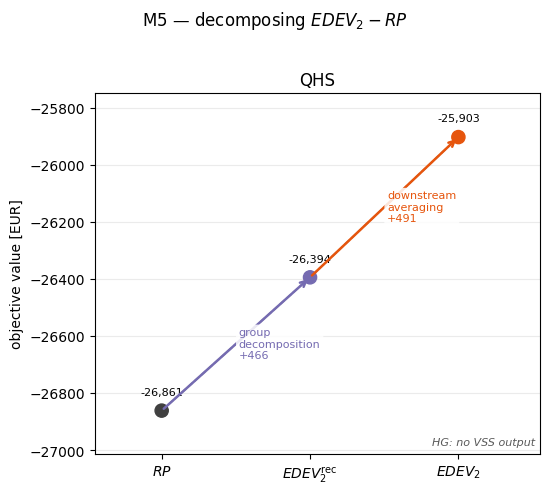

In [18]:
if dynamic.empty:
    print("M5 figure not rendered.")
else:
    n_panels = len(AVAILABLE)
    fig, axes = plt.subplots(1, n_panels, figsize=(5.6 * n_panels, 4.8), squeeze=False)
    for ax, form in zip(axes[0], AVAILABLE):
        row = gap.loc[form]
        stations = [("$RP$", row["RP"]),
                    (r"$EDEV^{\mathrm{rec}}_2$", row["EDEV_2_recourse"]),
                    ("$EDEV_2$", row["EDEV_2"])]
        xs, ys = np.arange(3), [v for _, v in stations]
        ax.plot(xs, ys, color="0.35", lw=1.2, ls="--", zorder=1)
        ax.scatter(xs, ys, s=90, zorder=3,
                   color=["0.25", CHAIN_COLORS["recourse"], CHAIN_COLORS["dynamic"]])
        for x, (_, v) in zip(xs, stations):
            ax.annotate(f"{v:,.0f}", (x, v), textcoords="offset points",
                        xytext=(0, 11), ha="center", fontsize=8)
        ax.annotate("", xy=(1, row["EDEV_2_recourse"]), xytext=(0, row["RP"]),
                    arrowprops=dict(arrowstyle="->", color=CHAIN_COLORS["recourse"], lw=1.8))
        ax.annotate("", xy=(2, row["EDEV_2"]), xytext=(1, row["EDEV_2_recourse"]),
                    arrowprops=dict(arrowstyle="->", color=CHAIN_COLORS["dynamic"], lw=1.8))
        box = dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85)
        ax.text(0.52, (row["RP"] + row["EDEV_2_recourse"]) / 2,
                f"group\ndecomposition\n{row['group_decomposition']:+,.0f}",
                fontsize=8, va="center", ha="left",
                color=CHAIN_COLORS["recourse"], bbox=box, zorder=4)
        ax.text(1.52, (row["EDEV_2_recourse"] + row["EDEV_2"]) / 2,
                f"downstream\naveraging\n{row['downstream_averaging']:+,.0f}",
                fontsize=8, va="center", ha="left",
                color=CHAIN_COLORS["dynamic"], bbox=box, zorder=4)
        ax.set_xticks(xs)
        ax.set_xticklabels([n for n, _ in stations])
        ax.set_xlim(-0.45, 2.55)
        ax.margins(y=0.16)
        ax.set_title(form)
        ax.grid(alpha=0.25, axis="y")
    axes[0][0].set_ylabel("objective value [EUR]")
    note_missing(axes[0][-1])
    finish(fig, r"M5 — decomposing $EDEV_2 - RP$")

---
## M6 — Where stochasticity matters

The reporting frame's fourth item: *"at which macro-stages the information is most
valuable, read from the shape of the static chain."*

The chain is read as increments. $VSS_\tau - VSS_{\tau-1} = EEV_{\tau-1} - EEV_\tau$ is
the cost of additionally committing macro-stage $\tau-1$ from the average forecast, given
that everything before it has already been committed — and `prop:static-guarantee` makes
every increment non-negative. As a share of the end-of-chain value the increments
decompose $VSS_{T}$ across the six market sessions, so the largest bar names the session
at which entering with an averaged decision costs most.

$VSS_1 = 0$ by construction, so the first increment is attached to $\tau = 2$ and is
labelled by the stage it commits, DA.

In [19]:
if static.empty:
    print("M6 not computable: no static chain.")
else:
    inc = static.sort_values(["run_dir", "tau"]).copy()
    inc["delta_VSS"] = inc.groupby("run_dir")["VSS"].diff()
    inc = inc.dropna(subset=["delta_VSS"])
    end = static[static["tau"] == TAU_LAST].set_index("run_dir")["VSS"]
    inc["delta_share_of_end"] = 100.0 * inc["delta_VSS"] / inc["run_dir"].map(end)
    inc["committed_stage"] = inc["tau"].map(lambda t: MACRO_STAGES[t - 2])

    m6 = inc.pivot_table(index="formulation", columns="committed_stage",
                         values=["delta_VSS", "delta_share_of_end"])
    stage_order = [s for s in MACRO_STAGES if s in inc["committed_stage"].unique()]
    m6 = m6.reindex([f for f in ORDER if f in AVAILABLE])
    print("M6 -- increment contributed by committing each macro-stage from the average")
    print(m6.round(2).to_string())
    print()
    shares = inc.pivot_table(index="formulation", columns="committed_stage",
                             values="delta_share_of_end")[stage_order]
    shares = shares.reindex([f for f in ORDER if f in AVAILABLE])
    print("Largest single increment, per formulation:")
    print(shares.idxmax(axis=1).rename("largest_increment").to_frame().to_string())

M6 -- increment contributed by committing each macro-stage from the average
                delta_VSS                              delta_share_of_end                           
committed_stage        DA     IM1    IM2    IM3     RM                 DA    IM1   IM2    IM3     RM
formulation                                                                                         
QHS                 97.36  121.74  60.19  98.87  391.5              12.65  15.82  7.82  12.85  50.87

Largest single increment, per formulation:
            largest_increment
formulation                  
QHS                        RM


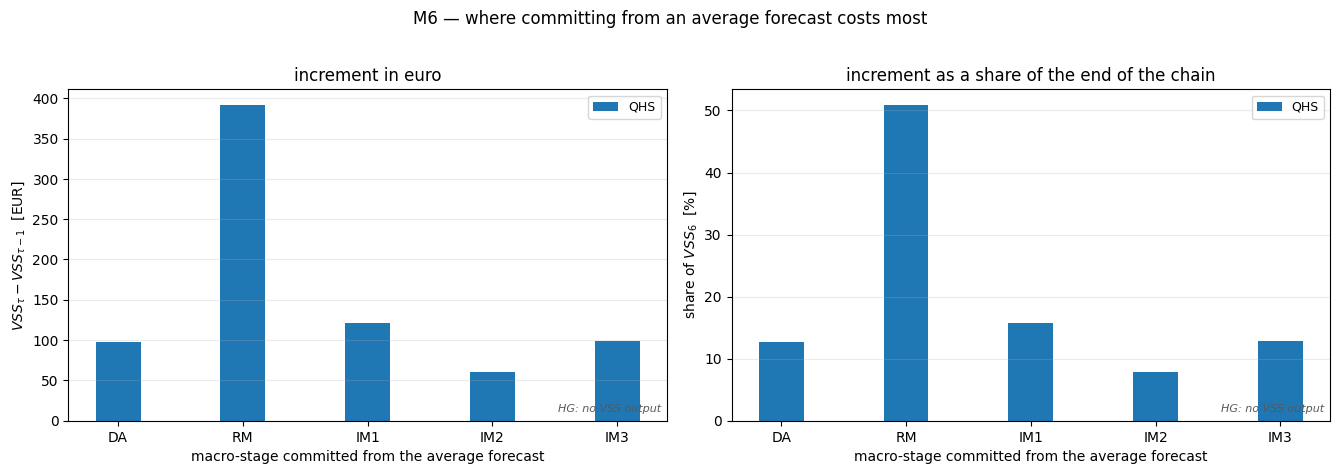

In [20]:
if static.empty:
    print("M6 figure not rendered.")
else:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR)
    labels = [f for f in ORDER if f in AVAILABLE]
    pos, width = bar_positions(stage_order), 0.36

    for i, form in enumerate(labels):
        offset = (i - (len(labels) - 1) / 2) * width
        axes[0].bar(pos + offset, [inc.loc[(inc.formulation == form)
                                           & (inc.committed_stage == s), "delta_VSS"].iloc[0]
                                   for s in stage_order],
                    width, color=COLORS[form], label=form)
        axes[1].bar(pos + offset, [shares.loc[form, s] for s in stage_order],
                    width, color=COLORS[form], label=form)

    axes[0].set_ylabel(r"$VSS_\tau - VSS_{\tau-1}$  [EUR]")
    axes[0].set_title("increment in euro")
    axes[1].set_ylabel(rf"share of $VSS_{{{TAU_LAST}}}$  [%]")
    axes[1].set_title("increment as a share of the end of the chain")
    for ax in axes:
        ax.set_xticks(pos)
        ax.set_xticklabels(stage_order)
        ax.set_xlabel("macro-stage committed from the average forecast")
        ax.grid(alpha=0.25, axis="y")
        ax.legend(fontsize=9)
        note_missing(ax)
    finish(fig, r"M6 — where committing from an average forecast costs most")

---
## M7 — Probability mass discarded, beside the values it produced

`subsec:vss-exclusion` requires this pairing, not merely the availability of both
numbers: *"A value obtained after discarding a non-negligible share of the probability
mass is a value computed on a different problem, and reporting the two together is what
keeps it honest."*

Two different mechanisms write into this column:

- **Static chain** — scenario-level exclusion driven by a Gurobi IIS, since the natural
  unit of failure there is an individual scenario.
- **Dynamic chain** — group-level exclusion (`edev_vssd.compute_edev_t`), matching the
  granularity at which its subproblems are defined; surviving groups' weights are
  renormalised to sum to one.

Where the mass is non-zero, the affected chain's monotonicity may break for that reason
alone, and M8 reads any such break in that light.

In [21]:
if static.empty or dynamic.empty:
    print("M7 not computable: both chains are needed.")
else:
    m7 = (static[["formulation", "tau", "macro_stage", "EEV", "VSS", "excluded_mass"]]
          .rename(columns={"excluded_mass": "static_excluded_mass"})
          .merge(dynamic[["formulation", "tau", "EDEV", "VSSD", "excluded_mass"]]
                 .rename(columns={"excluded_mass": "dynamic_excluded_mass"}),
                 on=["formulation", "tau"])
          .sort_values(["formulation", "tau"]))

    n_affected = int(((m7["static_excluded_mass"] > 0)
                      | (m7["dynamic_excluded_mass"] > 0)).sum())
    if n_affected == 0:
        print("No value in either chain was obtained after discarding probability mass.")
    else:
        print(f"{n_affected} of {len(m7)} (formulation, stage) values were obtained "
              f"after discarding probability mass.")
    print()
    print(m7.round(4).to_string(index=False))

No value in either chain was obtained after discarding probability mass.

formulation  tau macro_stage         EEV      VSS  static_excluded_mass        EDEV      VSSD  dynamic_excluded_mass
        QHS    1          DA -26860.6482   0.0000                   0.0 -25873.1615 -987.4867                    0.0
        QHS    2          RM -26958.0094  97.3612                   0.0 -25903.4659 -957.1824                    0.0
        QHS    3         IM1 -27349.5052 488.8570                   0.0 -25989.2427 -871.4055                    0.0
        QHS    4         IM2 -27471.2422 610.5939                   0.0 -25989.2427 -871.4055                    0.0
        QHS    5         IM3 -27531.4314 670.7832                   0.0 -26317.7728 -542.8754                    0.0
        QHS    6          IB -27630.3053 769.6571                   0.0 -26377.1411 -483.5071                    0.0


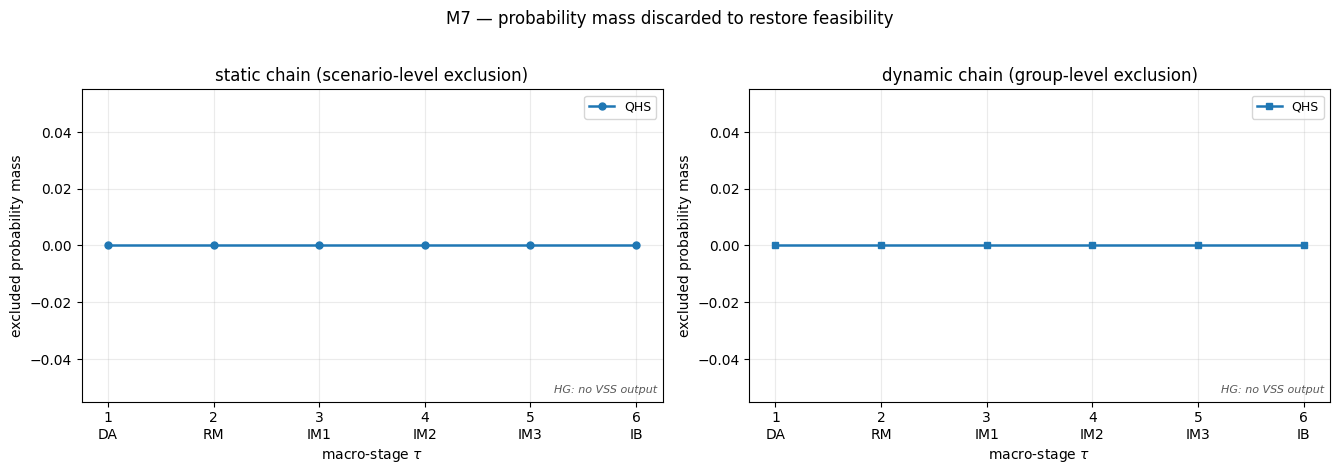

In [22]:
if static.empty or dynamic.empty:
    print("M7 figure not rendered.")
else:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharex=True)
    for form in AVAILABLE:
        s, d = series(static, form, "excluded_mass"), series(dynamic, form, "excluded_mass")
        axes[0].plot(s["tau"], s["excluded_mass"], color=COLORS[form], marker="o",
                     ms=5, lw=1.8, label=form)
        axes[1].plot(d["tau"], d["excluded_mass"], color=COLORS[form], marker="s",
                     ms=5, lw=1.8, label=form)
    axes[0].set_title("static chain (scenario-level exclusion)")
    axes[1].set_title("dynamic chain (group-level exclusion)")
    for ax in axes:
        stage_axis(ax)
        ax.set_ylabel("excluded probability mass")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)
        note_missing(ax)
    finish(fig, "M7 — probability mass discarded to restore feasibility")

---
## M8 — Verification of the properties audited in `tab:props`

The chapter closes on this. Each property is evaluated per formulation and reported
beside the status `tab:props` assigns it — several are *expected* to fail, so a table
showing only pass/fail would misrepresent the methods chapter.

> **Provenance.** `validation.py` emits its report to stdout and it is not persisted
> anywhere under `results/`. The predicates below are recomputed from the published CSVs,
> following `validation.py` statement by statement. A faithful reimplementation, not a
> recovered artefact.
>
> **Two tolerances.** Every inequality uses `validation.py`'s own absolute
> `DEFAULT_TOL = 1e-6`. The three equality identities use the scale-aware comparator of
> the setup cell instead: on quantities of order $10^4$ EUR an absolute $10^{-6}$
> threshold tests the eleventh significant digit and reports ordinary solver float noise
> as a failed theorem.
>
> **Propositions 4 and 6 share one predicate** and will always return the same verdict.
> They are kept separate because `tab:props` and `validation.py` keep them separate: they
> differ in *why* the inequality is expected (Jensen versus feasibility) and in status —
> Proposition 4 is checked informationally only, its hypothesis being violated by the
> stochastic objective coefficients.

In [23]:
EXPECTED_STATUS = {
    "Prop. 1 / Cor. 1: EEV_{t+1} <= EEV_t": "Guaranteed",
    "Prop. 1 / Cor. 1: VSS_t >= 0": "Guaranteed",
    "Prop. 1 / Cor. 1: VSS_t <= VSS_{t+1}": "Guaranteed",
    "Prop. 2: VSS_t <= EV - EEV_t": "Not applicable",
    "Prop. 4 (informational): EDEV_{t+1} <= EDEV_t": "Not applicable",
    "Prop. 5: VSSD >= 0": "Not guaranteed",
    "Prop. 6: EDEV_{t+1} <= EDEV_t": "Not guaranteed",
    "Prop. 7: VSSD_t >= 0": "Not guaranteed",
    "Prop. 7: VSSD_t <= VSSD_{t+1}": "Not guaranteed",
    "EDEV_1 == EV": "False here",
    "EDEV_2 == EDEV_1": "Expected",
    "EEV_1 == RP (by construction)": "Definition",
}


def check_formulation(form):
    s = static[static["formulation"] == form].set_index("tau").sort_index()
    d = dynamic[dynamic["formulation"] == form].set_index("tau").sort_index()
    sc = scalars.set_index("formulation").loc[form]
    tol, out = VALIDATION_TOL, {}

    def record(name, results):
        out[name] = (int(sum(results)), len(results))

    record("EEV_1 == RP (by construction)",
           [equal_within_scale(s.loc[1, "EEV"], sc["RP"])])
    record("Prop. 1 / Cor. 1: EEV_{t+1} <= EEV_t",
           [s.loc[t + 1, "EEV"] <= s.loc[t, "EEV"] + tol for t in TAUS[:-1]])
    record("Prop. 1 / Cor. 1: VSS_t >= 0", [s.loc[t, "VSS"] >= -tol for t in TAUS])
    record("Prop. 1 / Cor. 1: VSS_t <= VSS_{t+1}",
           [s.loc[t + 1, "VSS"] >= s.loc[t, "VSS"] - tol for t in TAUS[:-1]])
    record("Prop. 2: VSS_t <= EV - EEV_t",
           [s.loc[t, "VSS"] <= (sc["EV"] - s.loc[t, "EEV"]) + tol for t in TAUS])
    record("Prop. 4 (informational): EDEV_{t+1} <= EDEV_t",
           [d.loc[t + 1, "EDEV"] <= d.loc[t, "EDEV"] + tol for t in TAUS[:-1]])
    record("Prop. 5: VSSD >= 0", [sc["VSSD"] >= -tol])
    record("Prop. 6: EDEV_{t+1} <= EDEV_t",
           [d.loc[t + 1, "EDEV"] <= d.loc[t, "EDEV"] + tol for t in TAUS[:-1]])
    record("Prop. 7: VSSD_t >= 0", [d.loc[t, "VSSD"] >= -tol for t in TAUS])
    record("Prop. 7: VSSD_t <= VSSD_{t+1}",
           [d.loc[t + 1, "VSSD"] >= d.loc[t, "VSSD"] - tol for t in TAUS[:-1]])
    record("EDEV_1 == EV", [equal_within_scale(d.loc[1, "EDEV"], sc["EV"])])
    record("EDEV_2 == EDEV_1",
           [equal_within_scale(d.loc[2, "EDEV"], d.loc[1, "EDEV"])])
    return out


if static.empty or dynamic.empty:
    print("M8 not computable: both chains are needed.")
    tab_props = pd.DataFrame()
else:
    rows = []
    for form in AVAILABLE:
        for prop, (n_ok, n_tested) in check_formulation(form).items():
            rows.append({"formulation": form, "property": prop, "n_ok": n_ok,
                         "n_tested": n_tested,
                         "verdict": "holds" if n_ok == n_tested else "fails",
                         "checks": f"{n_ok}/{n_tested}"})
    checks = pd.DataFrame(rows)
    tab_props = checks.pivot(index="property", columns="formulation",
                             values=["verdict", "checks"])
    tab_props.columns = [f"{form}.{field}" for field, form in tab_props.columns]
    tab_props.insert(0, "expected (tab:props)",
                     pd.Series(EXPECTED_STATUS).reindex(tab_props.index))
    tab_props = tab_props.reindex([p for p in EXPECTED_STATUS if p in tab_props.index])
    print("M8 -- tab:props verification at the matched configuration")

tab_props

M8 -- tab:props verification at the matched configuration


,expected (tab:props),QHS.verdict,QHS.checks
property,,,
Prop. 1 / Cor. 1: EEV_{t+1} <= EEV_t,Guaranteed,holds,5/5
Prop. 1 / Cor. 1: VSS_t >= 0,Guaranteed,holds,6/6
Prop. 1 / Cor. 1: VSS_t <= VSS_{t+1},Guaranteed,holds,5/5
Prop. 2: VSS_t <= EV - EEV_t,Not applicable,fails,0/6
Prop. 4 (informational): EDEV_{t+1} <= EDEV_t,Not applicable,holds,5/5
Prop. 5: VSSD >= 0,Not guaranteed,fails,0/1
Prop. 6: EDEV_{t+1} <= EDEV_t,Not guaranteed,holds,5/5
Prop. 7: VSSD_t >= 0,Not guaranteed,fails,0/6
Prop. 7: VSSD_t <= VSSD_{t+1},Not guaranteed,holds,5/5


In [24]:
# Cross-reference any dynamic monotonicity failure against the excluded mass:
# renormalising after an exclusion can lift EDEV_{t+1} above EDEV_t on its own.
# A step that clears the absolute tolerance but not the scale-aware one is two
# numerically indistinguishable values, not a violated theorem.
if dynamic.empty:
    print("Not computable: no dynamic chain.")
else:
    mono = dynamic.sort_values(["formulation", "tau"]).copy()
    mono["EDEV_prev"] = mono.groupby("formulation")["EDEV"].shift(1)
    mono["excluded_prev"] = mono.groupby("formulation")["excluded_mass"].shift(1)
    mono = mono.dropna(subset=["EDEV_prev"])
    mono["rise_EUR"] = mono["EDEV"] - mono["EDEV_prev"]
    mono["rise_rel"] = mono["rise_EUR"] / mono["EDEV_prev"].abs()
    mono["violates_prop6"] = mono["EDEV"] > mono["EDEV_prev"] + VALIDATION_TOL
    mono["numerically_tied"] = [equal_within_scale(a, b)
                                for a, b in zip(mono["EDEV"], mono["EDEV_prev"])]
    mono["mass_changed_here"] = (mono["excluded_mass"] - mono["excluded_prev"]).abs() > 0

    viol = mono[mono["violates_prop6"]]
    if viol.empty:
        print("Proposition 6 (EDEV_{t+1} <= EDEV_t) is not violated in either run.")
    else:
        print("Steps failing Proposition 6 at validation.py's absolute tolerance:")
        print(viol[["formulation", "tau", "macro_stage", "EDEV_prev", "EDEV",
                    "rise_EUR", "rise_rel", "numerically_tied", "excluded_prev",
                    "excluded_mass", "mass_changed_here"]]
              .to_string(index=False, float_format=lambda v: f"{v:.4g}"))
        material = viol[~viol["numerically_tied"]]
        print(f"\n{len(viol)} steps fail the absolute test; {len(material)} are material "
              f"(the rest are numerically tied values).")
        if not material.empty:
            print(f"{int(material['mass_changed_here'].sum())} of the {len(material)} "
                  f"material violations occur where the excluded mass changes.")

Proposition 6 (EDEV_{t+1} <= EDEV_t) is not violated in either run.


---
## M9 — Constraints violated and infeasibility margins

> ### ❌ NOT COMPUTABLE — kept here so the gap stays visible
>
> The chapter's reporting frame asks for *"which constraints were implicated in the
> infeasibilities encountered, and by what margin."* **No artefact recording that exists
> anywhere under `../Execution of model/results/`.**
>
> What *is* recorded is the excluded probability mass (M7) — *how much* was discarded,
> never *why*. The identity of the implicated constraints and their violation margins are
> computed inside `ev_subproblem.py`'s IIS exclusion loop, used to decide which scenarios
> to drop, and then discarded.
>
> **Do not fill this gap from `subsec:vss-infeasibility`.** Those numbers — ten rounds,
> $19.0\%$ of the probability mass, a single `eq:da-mono` row naming one pair of retained
> scenarios — belong to the **abandoned** first $EEV_2$ construction, which was replaced
> precisely because it did not converge. They are diagnostic evidence for a design
> decision, not results of the chains reported here.
>
> **What would close it.** Per exclusion round, one row of: round index, macro-stage
> $\tau$, the IIS constraint names, the scenario indices parsed from both variable
> references *and* constraint names (`subsec:vss-exclusion` notes that a fully-fixed
> monotonicity row is presolved to a constant row whose only surviving record of its
> scenarios is its own name), the mass excluded that round, and the cumulative mass.
> Written to `<run>/DA/ec/001/iis_exclusions.csv`, this item becomes a table with no
> further modelling work.

In [25]:
# Search for any persisted IIS / exclusion artefact for the two pinned runs, so
# this section answers itself as soon as one exists.
IIS_PATTERNS = ["*iis*", "*IIS*", "*infeas*", "*exclusion*"]
found = []
for run_dir in REQUESTED_RUNS.values():
    for pattern in IIS_PATTERNS:
        for depth in ("*", os.path.join("*", "*"), os.path.join("*", "*", "*")):
            found.extend(glob.glob(os.path.join(RESULTS_DIR, run_dir, depth, pattern)))
found = sorted({f for f in found if os.path.isfile(f)})

if not found:
    print("No IIS or exclusion artefact found for either pinned run.")
    print("M9 remains not computable. See the note above for what would close it.")
else:
    print(f"{len(found)} candidate artefact(s) found -- M9 may now be computable:")
    for path in found[:40]:
        print("  ", os.path.relpath(path, RESULTS_DIR))

No IIS or exclusion artefact found for either pinned run.
M9 remains not computable. See the note above for what would close it.


---
## Coverage summary

Every item, and what the two pinned runs currently support.

In [26]:
summary_rows = [
    ("M1", "RP, Z_EV, and Z_EV - RP", not scalars.empty),
    ("M2", "Static chain: EEV_t and VSS_t", not static.empty),
    ("M3", "Dynamic chain: EDEV_t, VSSD_t, EDEV_2_recourse", not dynamic.empty),
    ("M4", "Both chains side by side", not (static.empty or dynamic.empty)),
    ("M5", "Dynamic gap decomposed via EDEV_2_recourse", not dynamic.empty),
    ("M6", "Where stochasticity matters: static-chain increments", not static.empty),
    ("M7", "Probability mass discarded beside its values", not (static.empty or dynamic.empty)),
    ("M8", "tab:props verification", not (static.empty or dynamic.empty)),
    ("M9", "Constraints violated and infeasibility margins", bool(found)),
]


def status_label(rendered):
    if not rendered:
        return "not rendered"
    return "rendered (both formulations)" if BOTH else f"rendered ({', '.join(AVAILABLE)} only)"


coverage_summary = pd.DataFrame(
    [(item, what, status_label(ok)) for item, what, ok in summary_rows],
    columns=["item", "what it shows", "status"])
coverage_summary.loc[coverage_summary["item"] == "M9", "status"] = (
    "rendered" if found else "NOT COMPUTABLE: no IIS artefact is written")

print(f"requested pair : HG = {REQUESTED_RUNS['HG']}")
print(f"                 QHS = {REQUESTED_RUNS['QHS']}")
print(f"VSS available  : {', '.join(AVAILABLE) if AVAILABLE else 'neither'}")
if MISSING:
    print(f"VSS missing    : {', '.join(MISSING)}")
coverage_summary

requested pair : HG = FTC_20251031_20251130_c30_sc560_15min_same_ren
                 QHS = FTC_20251031_20251130_c30_sc170_15min_different_ren
VSS available  : QHS
VSS missing    : HG


,item,what it shows,status
0,M1,"RP, Z_EV, and Z_EV - RP",rendered (QHS only)
1,M2,Static chain: EEV_t and VSS_t,rendered (QHS only)
2,M3,"Dynamic chain: EDEV_t, VSSD_t, EDEV_2_recourse",rendered (QHS only)
3,M4,Both chains side by side,rendered (QHS only)
4,M5,Dynamic gap decomposed via EDEV_2_recourse,rendered (QHS only)
5,M6,Where stochasticity matters: static-chain incr...,rendered (QHS only)
6,M7,Probability mass discarded beside its values,rendered (QHS only)
7,M8,tab:props verification,rendered (QHS only)
8,M9,Constraints violated and infeasibility margins,NOT COMPUTABLE: no IIS artefact is written


### If one of the two runs is still missing

Nothing in this notebook needs changing. The run is pinned by directory name in the setup
cell; once `run_static_vss.py` and `run_vssd.py` have been run for it and the two CSVs
land in `<run>/DA/ec/001/`, re-executing the notebook fills in every section, the
availability banner turns green for both, and the matched-count assertion checks that the
pair really is matched at $\lvert\Omega\rvert = 146$.

To compare a different pair instead, edit `REQUESTED_RUNS` and `EXPECTED_RETAINED` in the
setup cell. To compare across many trees rather than two, use
`section_5_3_value_of_stochastic_solution.ipynb`, which discovers every run with VSS
output automatically.